# 10 — Build GPT From Scratch (A Transformer Language Model)

In Project 09 you trained an **LSTM** to write Shakespeare one character at a time. It worked — but the LSTM has a hidden weakness: it reads text strictly left-to-right, squeezing everything it has seen so far into a single fixed-size memory vector. By the time it reaches the end of a long line, the beginning has been blurred into that one vector.

In Project 09 (ViT) you *used* a Transformer — but as a pretrained black box. You never saw what was inside.

**This project opens the box.** We're going to build the **Transformer** — specifically a **GPT-style decoder** — completely from scratch. Same task as Project 09 (predict the next character), same Shakespeare data, so we can compare the two architectures head-to-head on the exact same problem.

**The one big new idea: *attention*.** Instead of cramming the past into a single memory vector, every position gets to look *directly* at every earlier position and decide, for itself, which ones matter. That's it. That single change is what took us from the LSTMs of 2015 to the GPTs of today.

**What you'll learn:**
1. Why the LSTM's single memory vector is a bottleneck
2. **Self-attention** — Query / Key / Value, built from three `Linear` layers
3. **Causal masking** — how we stop a position from "cheating" by looking at the future
4. **Multi-head attention** — several attention patterns running in parallel
5. **Positional embeddings** — how a model with no recurrence knows word order
6. The full **Transformer block**: attention + feed-forward + residual connections + LayerNorm
7. Assembling these into a working GPT and watching it out-write the LSTM
8. **Visualizing the attention weights** — literally seeing what the model looks at

**The dataset:** the same Shakespeare corpus from Project 09, so the only thing that changes is the model.

## Setup

Identical setup to every other project: thread limits, device detection, and a fixed random seed for reproducibility.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path
import urllib.request
import time

# Device detection
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# torch.mps.manual_seed was added in PyTorch 2.1; guard against older versions
if torch.backends.mps.is_available() and hasattr(torch.mps, 'manual_seed'):
    torch.mps.manual_seed(SEED)
print(f'Random seed set to {SEED}')

Using device: mps
Random seed set to 42


---
## Part 1: The Data (Same as Project 09)

We reuse the exact Shakespeare pipeline from Project 09 — download the complete works, strip the Project Gutenberg boilerplate, and build a character-level vocabulary. Nothing here is new, so we move quickly. If the file is already on disk from Project 09, this just reloads it.

In [2]:
data_dir = Path.home() / "LocalAI" / "data" / "shakespeare"
data_dir.mkdir(parents=True, exist_ok=True)

file_path = data_dir / "shakespeare.txt"
url = "https://www.gutenberg.org/cache/epub/100/pg100.txt"

if not file_path.exists():
    print("Downloading Shakespeare's complete works (~5.5MB)...")
    urllib.request.urlretrieve(url, file_path)
    print("Done!")
else:
    print("Shakespeare already downloaded.")

with open(file_path, 'r', encoding='utf-8') as f:
    raw_text = f.read()

# Strip the Gutenberg header/footer boilerplate
start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"
start_idx = raw_text.find(start_marker)
end_idx = raw_text.find(end_marker)
if start_idx != -1 and end_idx != -1:
    start_idx = raw_text.find('\n', start_idx) + 1
    text = raw_text[start_idx:end_idx].strip()
else:
    text = raw_text

print(f"Cleaned text: {len(text):,} characters")

Shakespeare already downloaded.
Cleaned text: 5,359,342 characters


In [3]:
# Character-level vocabulary (same as Project 09)
chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the whole corpus as integer IDs
text_as_ids = np.array([char_to_idx[ch] for ch in text], dtype=np.int64)

print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Corpus encoded: {len(text_as_ids):,} integers")
print(f"First 60 decoded: {repr(''.join(idx_to_char[i] for i in text_as_ids[:60]))}")

Vocabulary size: 100 unique characters
Corpus encoded: 5,359,342 integers
First 60 decoded: 'The Complete Works of William Shakespeare\n\nby William Shakes'


---
## Part 2: Why Attention? The LSTM Bottleneck

Here's the core problem with the LSTM from Project 09.

An LSTM processes a sequence **one step at a time**, carrying a single hidden state (a fixed-size memory vector) from left to right:

```
"To be, or not to be"
  c1 -> c2 -> c3 -> ... -> c19
   \    \    \             /
    everything compressed into ONE vector
```

To predict the character after position 19, the LSTM can only use what survived in that one memory vector. Information from `c1` has been overwritten and re-mixed 18 times. Long-range dependencies (a quote that opened 200 characters ago, the subject of a long sentence) tend to fade.

**Attention throws out the single-memory idea.** Instead, at each position the model looks *directly* at every previous position and computes a weighted average of them — where the weights are learned and depend on the content:

```
position 19 asks: "given what I am, which of c1..c18 are relevant to me right now?"
            -> maybe c1 (the 'T') and c8 (the comma) matter most
            -> it reads mostly from those, ignoring the rest
```

No information bottleneck. No fixed memory vector. Every position has direct access to the full past, and *decides for itself* what to focus on. Three things fall out of this design:

- **It captures long-range dependencies** much better than an LSTM.
- **It's parallelizable** — every position is computed at once, not one-by-one. (This is why Transformers train so much faster on GPUs.)
- **It has no built-in sense of order** — which is a problem we'll have to fix with *positional embeddings* later.

Let's build it.

---
## Part 3: The Dataset

The dataset is the same idea as Project 09's `CharDataset`: the input is `block_size` characters, the target is those same characters **shifted left by one**. The model learns to predict the next character at *every* position simultaneously.

> **Design note:** We use **non-overlapping windows** (stride = `block_size`) for efficiency. A true sliding window with stride=1 would give ~100× more training examples but make each epoch take hours instead of seconds — impractical for experimentation. The model still sees every character as a target (each window predicts all positions), so no data is wasted.

The window size has a special name in Transformers: the **context length** or `block_size`. It's the maximum number of characters the model can attend to at once. (GPT-4's context is ~128k *tokens*; ours is a humble 128 *characters*.)

In [4]:
BLOCK_SIZE = 128  # context length: how many characters the model sees at once

class CharDataset(Dataset):
    """Non-overlapping windows: input = block_size chars, target = same chars shifted by one."""
    def __init__(self, text_ids, block_size):
        self.text_ids = text_ids
        self.block_size = block_size

    def __len__(self):
        # Non-overlapping windows (stride = block_size) — keeps training fast
        return (len(self.text_ids) - 1) // self.block_size

    def __getitem__(self, idx):
        start = idx * self.block_size
        input_seq = self.text_ids[start : start + self.block_size]
        target_seq = self.text_ids[start + 1 : start + self.block_size + 1]
        return (
            torch.tensor(input_seq, dtype=torch.long),
            torch.tensor(target_seq, dtype=torch.long),
        )

# 90/10 train/validation split
split_idx = int(len(text_as_ids) * 0.9)
train_ids = text_as_ids[:split_idx]
val_ids = text_as_ids[split_idx:]

train_dataset = CharDataset(train_ids, BLOCK_SIZE)
val_dataset = CharDataset(val_ids, BLOCK_SIZE)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Train examples: {len(train_dataset):,}  ({len(train_loader)} batches)")
print(f"Val examples:   {len(val_dataset):,}  ({len(val_loader)} batches)")

xb, yb = next(iter(train_loader))
print(f"\nBatch input shape:  {tuple(xb.shape)}  (batch, block_size)")
print(f"Batch target shape: {tuple(yb.shape)}")
print(f"Input  : {repr(''.join(idx_to_char[i.item()] for i in xb[0][:40]))}...")
print(f"Target : {repr(''.join(idx_to_char[i.item()] for i in yb[0][:40]))}...")

Train examples: 37,682  (588 batches)
Val examples:   4,186  (65 batches)

Batch input shape:  (64, 128)  (batch, block_size)
Batch target shape: (64, 128)
Input  : 'NEDICK.\n[Aside to Claudio.] You are a vi'...
Target : 'EDICK.\n[Aside to Claudio.] You are a vil'...


---
## Part 4: Self-Attention From Scratch

This is the heart of the whole project. Take your time here.

Every position produces **three** vectors by passing its embedding through three separate `Linear` layers:

| Vector | Question it answers | Analogy |
|--------|--------------------|---------|
| **Query** (Q) | "What am I looking for?" | your search box |
| **Key** (K) | "What do I contain?" | a web page's keywords |
| **Value** (V) | "What will I hand over if you pick me?" | the page's actual content |

The mechanism, step by step:

1. **Scores.** Each position's Query is compared against every position's Key with a dot product. High dot product = "this Key is relevant to my Query." This gives a `T x T` grid of attention scores.
2. **Scale.** Divide the scores by `sqrt(head_size)`. Without this, large dot products push the softmax into near-one-hot spikes and gradients vanish.
3. **Mask (causal).** Position 5 must NOT be allowed to look at positions 6, 7, 8... — that would be peeking at the answer it's trying to predict. We set those future scores to `-inf` so they become 0 after softmax. This **causal mask** is the single thing that makes it a *generative* (GPT-style) attention rather than the bidirectional attention used in BERT or the ViT you used earlier.
4. **Softmax.** Turn each row of scores into weights that sum to 1.
5. **Weighted sum.** Each position's output is the weighted average of all the **Value** vectors, using those weights.

That's one **attention head**. Here it is in code — notice it's mostly three `Linear` layers and two matrix multiplies.

In [5]:
class Head(nn.Module):
    """A single self-attention head with causal masking."""
    def __init__(self, n_embd, head_size, block_size, dropout):
        super().__init__()
        # Three independent projections of the input embedding
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # Lower-triangular matrix of ones. Registered as a buffer (not a parameter):
        # it's saved with the model but never trained. Used to build the causal mask.
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

        # NOT a registered buffer — this is a scratch attribute that holds the
        # most recent attention weights for visualization. Valid only immediately
        # after a forward() call on the same device.
        self.att = None

    def forward(self, x):
        # x: (batch, T, n_embd)
        B, T, C = x.shape
        k = self.key(x)     # (B, T, head_size)
        q = self.query(x)   # (B, T, head_size)

        # Step 1 + 2: scaled dot-product scores. (B, T, T)
        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)

        # Step 3: causal mask — zero out the future by setting it to -inf before softmax
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))

        # Step 4: softmax over the last dim -> each row sums to 1
        wei = torch.softmax(wei, dim=-1)
        self.att = wei.detach()  # save for visualization

        wei = self.dropout(wei)

        # Step 5: weighted sum of Values
        v = self.value(x)   # (B, T, head_size)
        out = wei @ v       # (B, T, head_size)
        return out

print("Head defined.")

Head defined.


### Multi-Head Attention

One head learns *one* kind of relationship — maybe "match each letter to the start of its word." But language has many relationships at once (subject-verb, open-quote/close-quote, vowel patterns...). So we run **several heads in parallel**, each with its own Q/K/V projections, then concatenate their outputs and mix them with one final `Linear` layer.

If `n_embd = 192` and `n_heads = 6`, each head works in a `192 / 6 = 32`-dimensional subspace. Concatenating the 6 heads gives us back `192`.

In [6]:
class MultiHeadAttention(nn.Module):
    """Several attention heads in parallel, concatenated and projected."""
    def __init__(self, n_heads, n_embd, head_size, block_size, dropout):
        super().__init__()
        self.heads = nn.ModuleList([
            Head(n_embd, head_size, block_size, dropout) for _ in range(n_heads)
        ])
        # Mixes the concatenated heads back into n_embd dimensions
        self.proj = nn.Linear(n_heads * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Run every head, concatenate along the feature dimension
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # (B, T, n_heads*head_size)
        out = self.dropout(self.proj(out))                   # (B, T, n_embd)
        return out

print("MultiHeadAttention defined.")

MultiHeadAttention defined.


### Feed-Forward + The Transformer Block

Attention lets positions *gather* information from each other. But after gathering, each position needs to *think* about what it collected. That's the job of a small **feed-forward network** (just two `Linear` layers with a non-linearity) applied independently at every position. It expands to `4 x n_embd` and back — the standard Transformer ratio.

A **Transformer block** wires these two pieces together with two tricks borrowed from earlier projects:

- **Residual connections** (`x = x + sublayer(x)`): the same idea as ResNet from your CNN work. They give gradients a clean highway straight through the network, which is what makes it possible to stack many blocks.
- **LayerNorm**: normalizes each position's vector to keep activations well-scaled. We apply it *before* each sublayer ("pre-norm"), which is what GPT-2 and essentially every modern LLM does because it trains more stably.

So one block is literally:

```
x = x + attention(layernorm(x))     # communicate
x = x + feedforward(layernorm(x))   # compute
```

In [7]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network: expand 4x, non-linearity, project back."""
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),                      # smoother cousin of ReLU; the LLM default
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """One Transformer block: pre-norm attention + pre-norm feed-forward, both with residuals."""
    def __init__(self, n_embd, n_heads, block_size, dropout):
        super().__init__()
        head_size = n_embd // n_heads
        self.sa = MultiHeadAttention(n_heads, n_embd, head_size, block_size, dropout)
        self.ff = FeedForward(n_embd, dropout)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))   # communicate: positions exchange info
        x = x + self.ff(self.ln2(x))   # compute: each position processes its own info
        return x

print("FeedForward and Block defined.")

FeedForward and Block defined.


### Positional Embeddings + The Full GPT

One catch we flagged earlier: attention is a *weighted average*, and an average doesn't care about order. To the attention math, `"dog bites man"` and `"man bites dog"` look identical. The LSTM got order for free because it stepped through the sequence in order — but our Transformer sees everything at once.

The fix is simple and clever: we keep a second embedding table indexed by **position** (0, 1, 2, ..., block_size-1) and **add** it to the character embedding. Now position 0 and position 5 start with different vectors even if they're the same character, so the model can learn order-dependent patterns.

The full model is then:

```
character IDs --> token embedding   |
position 0..T --> position embedding |  (added together)
              --> N stacked Transformer blocks
              --> final LayerNorm
              --> Linear to vocab_size  (a score for every possible next character)
```

In [8]:
class MiniGPT(nn.Module):
    """A small GPT-style decoder-only Transformer language model."""
    def __init__(self, vocab_size, n_embd=192, n_heads=6, n_layers=6,
                 block_size=BLOCK_SIZE, dropout=0.2):
        super().__init__()
        self.block_size = block_size

        # Two embedding tables: one for the character, one for its position
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)

        # The stack of Transformer blocks
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_heads, block_size, dropout) for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(n_embd)            # final norm
        self.fc = nn.Linear(n_embd, vocab_size)     # project to vocabulary scores

        self.apply(self._init_weights)

    def _init_weights(self, module):
        # Small normal init is what GPT-2 uses; helps training stability
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        # idx: (batch, T) integer character IDs
        B, T = idx.shape
        # Guard: position embedding only knows positions 0..block_size-1
        if T > self.block_size:
            raise ValueError(
                f"Input sequence length {T} exceeds block_size {self.block_size}. "
                f"Crop your input or increase block_size."
            )
        tok = self.token_embedding(idx)                                   # (B, T, n_embd)
        pos = self.position_embedding(torch.arange(T, device=idx.device)) # (T, n_embd)
        x = tok + pos                                                     # broadcast-add
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.fc(x)                                               # (B, T, vocab_size)
        return logits


model = MiniGPT(vocab_size).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"\nProject 09's LSTM had ~960K parameters.")
print(f"This GPT has {total_params/1e6:.1f}M parameters — and GPT-3 has 175,000M.")

MiniGPT(
  (token_embedding): Embedding(100, 192)
  (position_embedding): Embedding(128, 192)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-5): 6 x Head(
            (key): Linear(in_features=192, out_features=32, bias=False)
            (query): Linear(in_features=192, out_features=32, bias=False)
            (value): Linear(in_features=192, out_features=32, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=768, out_features=192, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (ln1): LayerNorm((192,), eps=1e-05, elementwise_affine=True,

---
## Part 5: Training

The training loop is the same shape as Project 09 — the loss is `CrossEntropyLoss` applied at **every** position (the model makes `block_size` predictions per example), and we track **perplexity** = `exp(loss)` so we can compare directly against the LSTM.

Two small, Transformer-flavored choices:
- **AdamW** instead of plain Adam — Adam with properly decoupled weight decay; the standard optimizer for Transformers.
- We keep the **gradient clipping** and **ReduceLROnPlateau** scheduler from Project 09 (with `patience=3` so the LR doesn't collapse after one wobbly epoch).

On an Apple-Silicon `mps` or a CUDA GPU this trains comfortably. On CPU it will be slow — drop `n_layers`, `n_embd`, or `N_EPOCHS` if needed (see the model config above).

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

N_EPOCHS = 8
train_losses, val_losses, val_perplexities = [], [], []

print(f"Training on {len(train_loader)} batches per epoch for {N_EPOCHS} epochs...\n")
start_time = time.time()

for epoch in range(N_EPOCHS):
    # --- TRAIN ---
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)                                  # (B, T, vocab)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATE ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    perplexity = np.exp(avg_val_loss)
    val_perplexities.append(perplexity)
    scheduler.step(avg_val_loss)

    elapsed = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1:2d}/{N_EPOCHS} | '
          f'Train Loss: {avg_train_loss:.3f} | Val Loss: {avg_val_loss:.3f} | '
          f'Perplexity: {perplexity:.1f} | LR: {current_lr:.1e} | Time: {elapsed:.0f}s')

print(f"\nTraining complete in {(time.time()-start_time)/60:.1f} min.")
print(f"Final validation perplexity: {val_perplexities[-1]:.1f}")

Training on 588 batches per epoch for 8 epochs...

Epoch  1/8 | Train Loss: 2.446 | Val Loss: 2.043 | Perplexity: 7.7 | LR: 3.0e-04 | Time: 45s
Epoch  2/8 | Train Loss: 1.923 | Val Loss: 1.785 | Perplexity: 6.0 | LR: 3.0e-04 | Time: 88s
Epoch  3/8 | Train Loss: 1.732 | Val Loss: 1.671 | Perplexity: 5.3 | LR: 3.0e-04 | Time: 131s
Epoch  4/8 | Train Loss: 1.622 | Val Loss: 1.608 | Perplexity: 5.0 | LR: 3.0e-04 | Time: 173s
Epoch  5/8 | Train Loss: 1.550 | Val Loss: 1.566 | Perplexity: 4.8 | LR: 3.0e-04 | Time: 216s
Epoch  6/8 | Train Loss: 1.500 | Val Loss: 1.542 | Perplexity: 4.7 | LR: 3.0e-04 | Time: 258s
Epoch  7/8 | Train Loss: 1.464 | Val Loss: 1.519 | Perplexity: 4.6 | LR: 3.0e-04 | Time: 300s
Epoch  8/8 | Train Loss: 1.437 | Val Loss: 1.499 | Perplexity: 4.5 | LR: 3.0e-04 | Time: 342s

Training complete in 5.7 min.
Final validation perplexity: 4.5


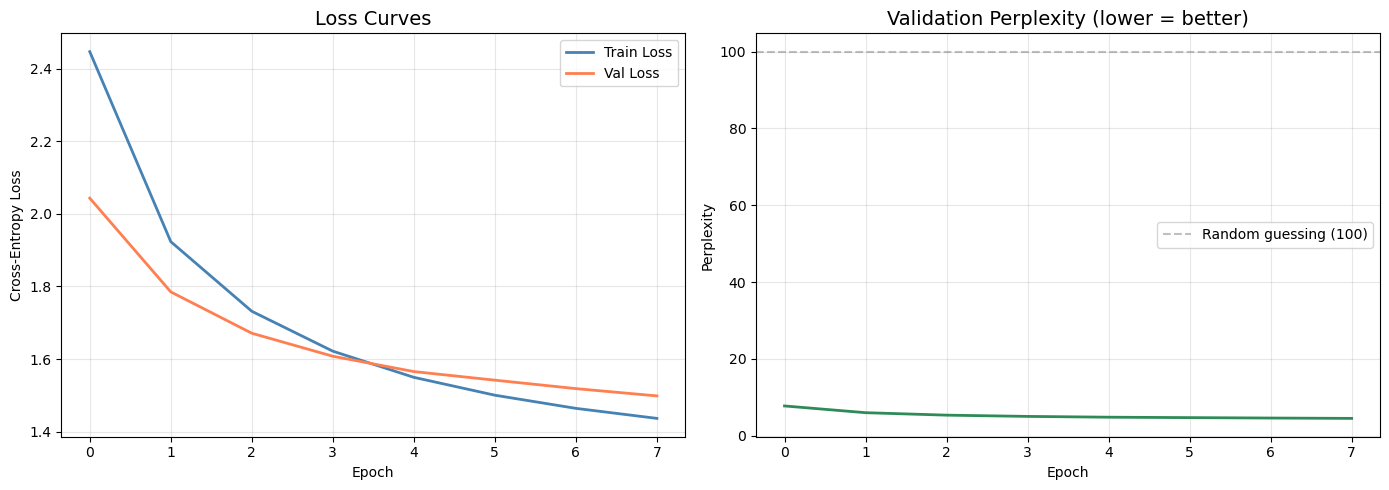

Final perplexity: 4.5
Project 09's LSTM typically landed around perplexity 5-7 on this data.
Compare your Transformer's number — same data, same task, different architecture.


In [10]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2, color='steelblue')
axes[0].plot(val_losses, label='Val Loss', linewidth=2, color='coral')
axes[0].set_title('Loss Curves', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(val_perplexities, linewidth=2, color='seagreen')
axes[1].axhline(y=vocab_size, color='gray', linestyle='--', alpha=0.5,
                label=f'Random guessing ({vocab_size})')
axes[1].set_title('Validation Perplexity (lower = better)', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Final perplexity: {val_perplexities[-1]:.1f}")
print("Project 09's LSTM typically landed around perplexity 5-7 on this data.")
print("Compare your Transformer's number — same data, same task, different architecture.")

---
## Part 6: Generating Text

Generation is **autoregressive**, exactly like Project 09: predict one character, append it, feed the whole thing back, repeat. The temperature knob works identically (low = safe/repetitive, high = wild/creative).

The one Transformer-specific detail: our model only has positional embeddings for `block_size` positions, so we must **crop the context to the last `block_size` characters** before each forward pass. The LSTM had no such limit because it carried a running hidden state — but it paid for that flexibility with the memory bottleneck.

In [11]:
@torch.no_grad()
def generate_text(model, start_text, char_to_idx, idx_to_char,
                  length=500, temperature=0.8, device=device):
    """Generate text autoregressively, cropping context to the model's block_size."""
    model.eval()
    # Unknown characters map to index 0 (matching Project 09's LSTM behavior).
    # In practice all standard ASCII appears in the Shakespeare vocab, so this
    # is a safety net for edge cases like curly quotes or emoji in the seed.
    idx = torch.tensor([[char_to_idx.get(ch, 0) for ch in start_text]],
                       dtype=torch.long, device=device)  # (1, len(start_text))

    for _ in range(length):
        idx_cond = idx[:, -model.block_size:]      # crop to the last block_size chars
        logits = model(idx_cond)                   # (1, T, vocab)
        logits = logits[:, -1, :]                  # take the last position's prediction
        if temperature > 0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)  # (1, 1)
        else:
            # Greedy decoding when temperature=0
            next_id = logits.argmax(dim=-1, keepdim=True)  # (1, 1)
        idx = torch.cat([idx, next_id], dim=1)

    return ''.join(idx_to_char[i] for i in idx[0].tolist())

print("Quick sample (temperature 0.8):\n")
print(generate_text(model, "ROMEO: ", char_to_idx, idx_to_char, length=300, temperature=0.8))

Quick sample (temperature 0.8):

ROMEO: Sir Toby,
                                181

GENTLEMAN.
I will see at Arbantis burdy mercy,
                                                                                            142

SECOND MURDERER.
Ay, what in there is be mother;—

 [_There are me o’er a coat._]

BERTRAM.
They did let see,


In [12]:
# Generate from several seeds
seed_texts = ["ROMEO: ", "JULIET: ", "HAMLET: ", "To be, or not to be"]

print("=" * 70)
print("GENERATED SHAKESPEARE (Transformer)")
print("=" * 70)
for seed in seed_texts:
    print(f"\n{'-' * 70}\nSEED: {repr(seed)}\n{'-' * 70}")
    print(generate_text(model, seed, char_to_idx, idx_to_char, length=400, temperature=0.7))

GENERATED SHAKESPEARE (Transformer)

----------------------------------------------------------------------
SEED: 'ROMEO: '
----------------------------------------------------------------------
ROMEO: they are something.

GRUMIO.
O good Double than the child; and the man that the court of Verona, the strong
excellented her means to his man, stander to dear whore, nor while
are the pircules of the charge of the true of good state!

SIR TOBY.
And there is the sweet painted of the banish words.

LADY MACBETH.
Where loves the prophet speak of the manners of the sword of thy sake
and dares and two c

----------------------------------------------------------------------
SEED: 'JULIET: '
----------------------------------------------------------------------
JULIET: my great lord, what I have breaking him with such a reproach of my body love,
were the world reasons to him but off.

MARCUS.
Here she comes and very courteous commanditions
Officers our graciously senses of me.

CELIA.
No, the K

In [13]:
# Temperature comparison — same seed, different randomness
seed = "ROMEO: "
for temp in [0.2, 0.5, 0.8, 1.2]:
    print(f"\n--- Temperature = {temp} ---")
    out = generate_text(model, seed, char_to_idx, idx_to_char, length=200, temperature=temp)
    print(out)

print("\nLow temp -> repetitive and safe. High temp -> creative but less coherent.")


--- Temperature = 0.2 ---
ROMEO: the King of Caesar and Servants.

CASSIO.
And the King of Caesar and the King of Cassio.

FIRST GENTLEMAN.
What is the court?

PAROLLES.
What is the man of the King?

CASSIO.
I will not see the sea of

--- Temperature = 0.5 ---
ROMEO: and the great thing the Duke of Northumberland’s house,
And the discovered of the time of the rest,
And the world of such as the discourse of the gods,
And she soul the uncle of the land whoreson the 

--- Temperature = 0.8 ---
ROMEO: say the traitor’s man of Cassio.

MARCUS.
Fear posting of Lucius arms. There’s and heart
The seat of self in ’twixt. So stay as:
The baside of line earthly the King by the dear service.

[_Exeunt all 

--- Temperature = 1.2 ---
ROMEO: you counsell, allowed; but knife conceit!
And the merchhand you was leastned.—Speak what, that I persuade,
But desperate ne’er saw as her a bigginions
His loudy beatenly, if thereuf, he would go a gen

Low temp -> repetitive and safe. High temp -> creative but 

---
## Part 7: Seeing What Attention Looks At

This is the payoff that the LSTM could never give us. Because we stashed each head's softmax weights in `head.att`, we can pull them out and **plot exactly which earlier characters each position chose to focus on.**

We feed a short phrase through the model, grab one head from the first block, and draw its `T x T` attention matrix. Read it row by row: **row `i` shows how much position `i` attended to each earlier position `j`.** The upper-right triangle is always blank — that's the causal mask doing its job, forbidding any position from looking at the future.

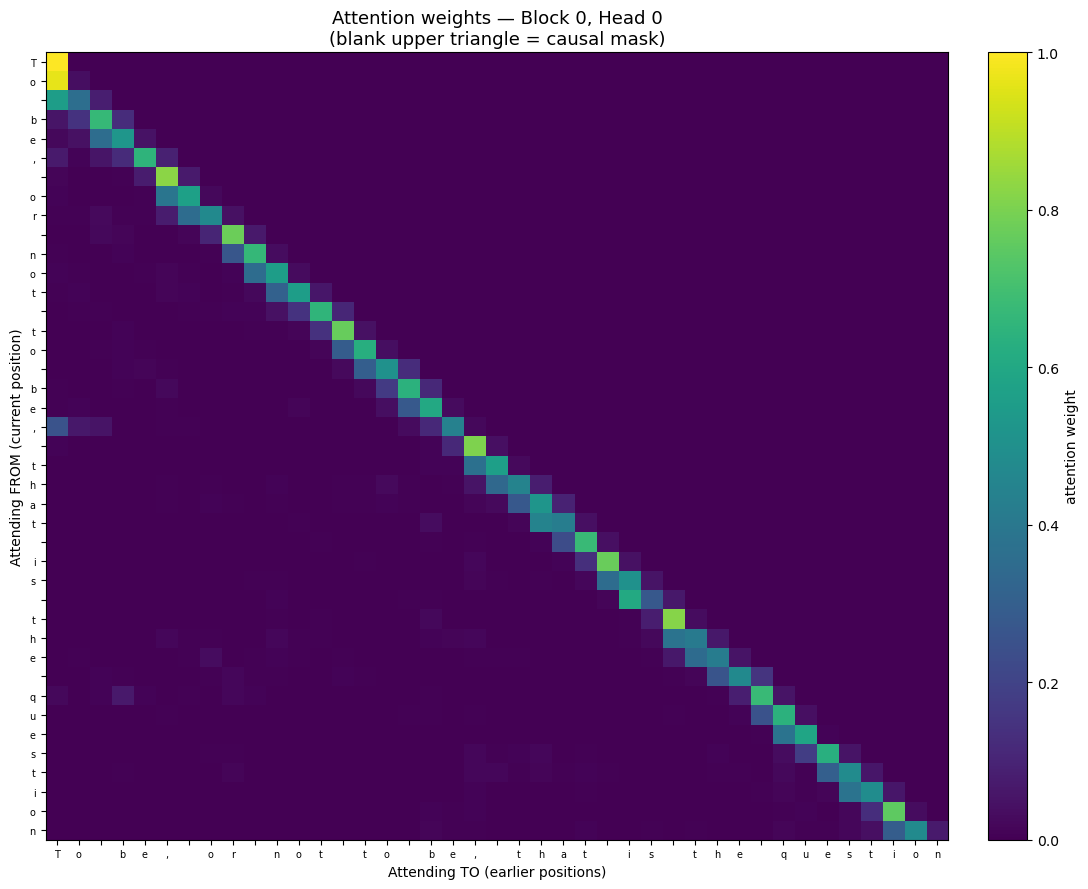

Each row sums to 1. Brighter = more attention.
Different heads/blocks learn different patterns — try changing the indices below.


In [14]:
# Run a short phrase through the model and capture attention from block 0
phrase = "To be, or not to be, that is the question"
ids = torch.tensor([[char_to_idx.get(ch, 0) for ch in phrase]], dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    _ = model(ids)

# Grab the attention weights from the first head of the first block: (B, T, T) -> (T, T)
att = model.blocks[0].sa.heads[0].att[0].cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(att, cmap='viridis', aspect='auto')

labels = [repr(ch)[1:-1] for ch in phrase]  # printable char labels
ax.set_xticks(range(len(phrase))); ax.set_xticklabels(labels, fontsize=7)
ax.set_yticks(range(len(phrase))); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Attending TO (earlier positions)")
ax.set_ylabel("Attending FROM (current position)")
ax.set_title("Attention weights — Block 0, Head 0\n(blank upper triangle = causal mask)", fontsize=13)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="attention weight")
plt.tight_layout(); plt.show()

print("Each row sums to 1. Brighter = more attention.")
print("Different heads/blocks learn different patterns — try changing the indices below.")

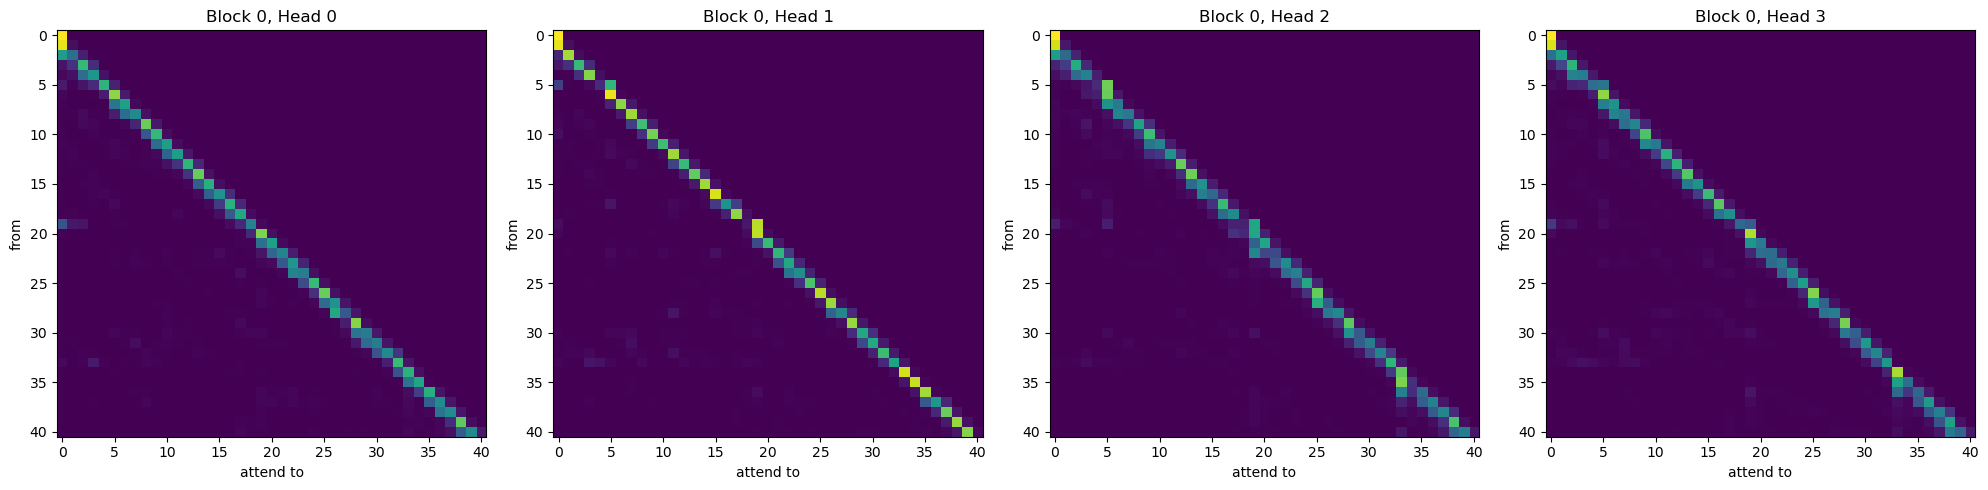

Notice how each head specializes in a different attention pattern.


In [15]:
# Compare a few heads side by side (block 0)
n_show = min(4, len(model.blocks[0].sa.heads))
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
if n_show == 1:
    axes = [axes]
for h in range(n_show):
    a = model.blocks[0].sa.heads[h].att[0].cpu().numpy()
    axes[h].imshow(a, cmap='viridis', aspect='auto')
    axes[h].set_title(f"Block 0, Head {h}")
    axes[h].set_xlabel("attend to"); axes[h].set_ylabel("from")
plt.tight_layout(); plt.show()

print("Notice how each head specializes in a different attention pattern.")

---
## What You Built

1. **Self-attention from scratch** — Query/Key/Value as three `Linear` layers, scaled dot-product scores, softmax, weighted sum of Values
2. **Causal masking** — the `-inf` trick that makes attention generative instead of bidirectional
3. **Multi-head attention** — several attention patterns in parallel
4. **The Transformer block** — pre-norm attention + feed-forward, glued with residual connections
5. **Positional embeddings** — giving an order-blind model a sense of sequence
6. A working **GPT** that generates Shakespeare and beats the LSTM on the same task
7. **Attention visualization** — literally seeing what the model looks at

## Key Concepts

| Concept | Meaning |
|---------|---------|
| Self-attention | Each position reads a learned weighted average of all earlier positions |
| Query / Key / Value | "what I want" / "what I contain" / "what I hand over" |
| Scaled dot-product | Q·K divided by sqrt(head_size) to keep softmax gradients healthy |
| Causal mask | Forces position i to ignore positions > i (no peeking at the future) |
| Multi-head | Multiple attention heads, each in its own subspace, then concatenated |
| Positional embedding | A learned vector per position, added so the model knows order |
| Residual + LayerNorm | Stable gradient highways that let us stack many blocks |
| Context length (block_size) | Max number of tokens attended to at once |

## LSTM (Project 09) vs Transformer (This Project)

| | LSTM | Transformer |
|---|------|-------------|
| How it sees the past | one running memory vector | direct access to every position |
| Long-range dependencies | fade over distance | preserved |
| Order awareness | free (steps in order) | added via positional embeddings |
| Parallelism | sequential (slow) | fully parallel (fast) |
| Powers... | older NLP, time series | GPT, Claude, Gemini, Llama, ViT |

## How This Connects to Real GPT

What you built **is** a GPT. The only differences from GPT-3/4 are scale and tokenization:

| Your MiniGPT | GPT-3 |
|--------------|-------|
| character tokens (~100 vocab) | Byte-Pair Encoding subwords (~50k vocab) |
| 6 layers, 6 heads | 96 layers, 96 heads |
| ~2-3M parameters | 175,000M parameters |
| 128-character context | thousands-of-token context |
| Shakespeare (~5MB) | internet-scale text (~45TB) |
| **identical core architecture** | **identical core architecture** |

---
## Things to Try

1. **Scale it up** — bump `n_layers`, `n_embd`, or `BLOCK_SIZE` and watch perplexity drop (until you run out of memory or patience).
2. **More epochs** — leave it training longer; the text keeps getting better.
3. **Visualize deeper layers** — change `model.blocks[0]` to `model.blocks[5]`. Later layers often attend in more abstract, longer-range ways.
4. **Remove positional embeddings** — comment out the `+ pos` line and retrain. How much worse does it get? (This proves order matters.)
5. **Remove the causal mask** — what happens to generation when the model is allowed to see the future during training?
6. **Train on your own text** — swap Shakespeare for song lyrics, code, or your chat logs.
7. **Try the official `nn.TransformerEncoderLayer`** — rebuild the same model with PyTorch's built-in block and confirm you get similar results.

---
## Bonus: Save and Reload

In [ ]:
model_dir = Path.home() / "LocalAI" / "models" / "mini_gpt"
model_dir.mkdir(parents=True, exist_ok=True)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'epoch': N_EPOCHS,
    'char_to_idx': char_to_idx,
    'idx_to_char': idx_to_char,
    'vocab_size': vocab_size,
    'chars': chars,
    'model_config': {
        'n_embd': 192,
        'n_heads': 6,
        'n_layers': 6,
        'block_size': BLOCK_SIZE,
        'dropout': 0.2,
    },
    'val_perplexity': val_perplexities[-1],
}

torch.save(checkpoint, model_dir / 'shakespeare_gpt.pt')
print(f"Model saved to {model_dir / 'shakespeare_gpt.pt'}")

reload_hint = (
    "To reload for inference (after restarting kernel, re-run cells through Part 5 \"Model\"):\n\n"
    "checkpoint = torch.load(model_dir / 'shakespeare_gpt.pt', map_location=device)\n"
    "model = MiniGPT(vocab_size=checkpoint['vocab_size'], **checkpoint['model_config']).to(device)\n"
    "model.load_state_dict(checkpoint['model_state_dict'])\n"
    "model.eval()\n"
    "# then call generate_text(...) with checkpoint['char_to_idx'] / checkpoint['idx_to_char']"
)
print(reload_hint)